In [32]:
%load_ext autoreload
%autoreload 2

from model import LitS4Model, LitS4DualModel
from data_20bins import LitDataModule
from plotting import *
import torch
from torch.utils.data import DataLoader, random_split, Subset, Dataset
device = 'cuda' if torch.cuda.is_available() else 'cpu'
import tqdm
import numpy as np
from models.networks import S4D_S4D_GatedModel, S4D_S4D_Model, S4DModel
import yaml
from scipy import signal
import glob
import pickle
import lightning as L
import h5py
from noise import noise_model, bandpass_filter
from utils import fft_func_IQ_complex_channels
import os

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [33]:
path = '/home/lfd34/project/project8/ssm/neutrino_project/runs/longer_tracks/s4d_fft_8kpoints_dmodel128_batch128_actual/lightning_logs/w1494itp'
CHECKPOINT = os.path.join(path, 'checkpoints/epoch=46-step=31114.ckpt')
image_folder = os.path.join(path, 'results')
config_path = os.path.join(path, "../../config.yaml")

In [34]:
with open(config_path) as config_file:
    config_data = yaml.safe_load(config_file)

if config_data['model']['class_path'] == 'model.LitS4Model':
    encoder_data = config_data['model']['init_args']['encoder']['init_args']
    encoder = S4DModel(
        d_input = encoder_data['d_input'],
        d_output = encoder_data['d_output'],
        d_model = encoder_data['d_model'],
        n_layers = encoder_data['n_layers'],
        dropout = encoder_data['dropout'],
        prenorm = encoder_data['prenorm'],
        fc_hidden = encoder_data['fc_hidden'],
        )
    model = LitS4Model.load_from_checkpoint(CHECKPOINT,
                encoder=encoder)

elif config_data['model']['class_path'] == 'model.LitS4DualModel':
    if config_data['model']['class_path']['encoder']['class_path'] == 'models.networks.S4D_S4D_GatedModel':
        encoder_data = config_data['model']['init_args']['encoder']['init_args']
        encoder = S4D_S4D_GatedModel(
            output_dim = encoder_data['output_dim'],
            d_input_ts = encoder_data['d_input_ts'],
            d_input_fft = encoder_data['d_input_fft'],
            s4d_ts_d_model = encoder_data['s4d_ts_d_model'],
            s4d_ts_n_layers = encoder_data['s4d_ts_n_layers'],
            s4d_ts_fc_hidden = encoder_data['s4d_ts_fc_hidden'],
            s4d_fft_d_model = encoder_data['s4d_fft_d_model'],
            s4d_fft_n_layers = encoder_data['s4d_fft_n_layers'],
            s4d_fft_fc_hidden = encoder_data['s4d_fft_fc_hidden'],
            combined_fc_hidden = encoder_data['combined_fc_hidden']    
            )
        model = LitS4DualModel.load_from_checkpoint(CHECKPOINT,
                encoder=encoder)
        
    elif config_data['model']['class_path']['encoder']['class_path'] == 'models.networks.S4D_S4D_Model':
        encoder_data = config_data['model']['init_args']['encoder']['init_args']
        encoder = S4D_S4D_Model(
            output_dim = encoder_data['output_dim'],
            d_input_ts = encoder_data['d_input_ts'],
            d_input_fft = encoder_data['d_input_fft'],
            s4d_ts_d_model = encoder_data['s4d_ts_d_model'],
            s4d_ts_n_layers = encoder_data['s4d_ts_n_layers'],
            s4d_ts_fc_hidden = encoder_data['s4d_ts_fc_hidden'],
            s4d_fft_d_model = encoder_data['s4d_fft_d_model'],
            s4d_fft_n_layers = encoder_data['s4d_fft_n_layers'],
            s4d_fft_fc_hidden = encoder_data['s4d_fft_fc_hidden'],
            combined_fc_hidden = encoder_data['combined_fc_hidden']    
            )
        model = LitS4DualModel.load_from_checkpoint(CHECKPOINT,
                encoder=encoder)

In [35]:
class Project8Sim(Dataset):
    def __init__(self, shard_paths, inputs, variables, observables,
            start= 0, cutoff=4000, norm=True, noise_const=1, apply_filter=False, apply_fft=False):

        self.shard_paths = shard_paths
        self.inputs = inputs
        self.variables = variables
        self.observables = observables
        self.start = start
        self.cutoff = cutoff
        self.norm = norm
        self.apply_filter = apply_filter
        self.noise_const = noise_const
        self.apply_fft = apply_fft

        self.index_map = []
        self.shard_lengths = []
        for shard_id, path in enumerate(shard_paths):
            with h5py.File(path, 'r') as f:
                num_rows = f[inputs[0]].shape[0]
                self.shard_lengths.append(num_rows)
                self.index_map.extend([(shard_id, i) for i in range(num_rows)])

        self.mu = np.array([18604.113   ,    88.995384], dtype=np.float32)
        self.stds = np.array([57.852913 ,  0.5772375], dtype=np.float32) 

    def __len__(self):
        return len(self.index_map)
    
    def __getitem__(self, idx):
        shard_id, local_idx = self.index_map[idx]
        shard_path = self.shard_paths[shard_id]
        
        with h5py.File(shard_path, 'r') as f:
            data_channels = []
            for i in self.inputs:
                ch_data = f[i][local_idx][self.start:self.cutoff].astype(np.float32)
                data_channels.append(ch_data)
            
            y_raw = []
            for v in self.variables:
                val = f[v][local_idx]
                y_raw.append(val.item() if np.ndim(val) >= 0 else val)
            y = np.array(y_raw, dtype=np.float32)

            obs_raw = []
            for o in self.observables:
                val = f[o][local_idx]
                obs_raw.append(val.item() if np.ndim(val) >= 0 else val)
                obs = np.array(obs_raw, dtype=np.float32)

        X_ts = np.stack(data_channels, axis=1)
        
        for j in range(X_ts.shape[1]):
            noise_arr = noise_model(self.cutoff - self.start, self.noise_const)
            X_noise = X_ts[:, j] + noise_arr
        
            if self.apply_filter:
                X_noise = bandpass_filter(X_noise)

            if self.norm:
                std_X = np.std(X_noise)
                X_ts[:, j] = X_noise / (std_X)
            else:
                X_ts[:, j] = X_noise
        
        if self.apply_fft:
            index_ts_I = self.inputs.index('output_ts_I')
            index_ts_Q = self.inputs.index('output_ts_Q')
            real_part, imag_part = fft_func_IQ_complex_channels(
                    X_ts[:, index_ts_I],
                    X_ts[:, index_ts_Q]
                )
            fft_case_data = np.stack([real_part, imag_part], axis=1) # (Length, 2)
            mu_fft = np.mean(fft_case_data, axis=0)
            std_fft = np.std(fft_case_data, axis=0)
            X_ts[:, index_ts_I] = (real_part - mu_fft[0]) / (std_fft[0])
            X_ts[:, index_ts_Q] = (imag_part - mu_fft[1]) / (std_fft[1])
        
        ts = torch.tensor(X_ts, dtype=torch.float32)
        var = torch.tensor((y - self.mu) / self.stds, dtype=torch.float32)
        obs = torch.tensor(obs, dtype=torch.float32)
        return ts, var, obs


    def outdim(self):
        return len(self.variables)
    
    def __indim__(self):
        return len(self.inputs)

class GenericDataModule(L.LightningDataModule):
    def __init__(self, batch_size=128, num_workers=4, pin_memory=False):
        super().__init__()
        self.batch_size = batch_size
        self.num_workers = num_workers
        self.pin_memory = pin_memory
        self.loader_kwargs = {
                "batch_size": self.batch_size,
                "num_workers": self.num_workers,
                "pin_memory": self.pin_memory
        }


class LitDataModule(GenericDataModule):
    def __init__(self, shard_dir, inputs, variables, observables, start = 0, cutoff=4000, norm=True, noise_const=1, apply_filter=False, apply_fft=False, use_curriculum_learning=False, **kwargs):
        super().__init__(**kwargs)
        
        self.shard_paths = sorted(glob.glob(os.path.join(shard_dir, "*.hdf5")))
        self.initial_noise_const = noise_const
        self.use_curriculum_learning = use_curriculum_learning
        
        self.dataset = Project8Sim(self.shard_paths, inputs, variables, observables, start= start, cutoff=cutoff, norm=norm, noise_const=noise_const, apply_filter=apply_filter, apply_fft=apply_fft)
        
        self.mu = self.dataset.mu
        self.stds = self.dataset.stds
        generator = torch.Generator().manual_seed(42)
        train_len = int(0.8 * len(self.dataset))
        val_len = int(0.1 * len(self.dataset))
        test_len = len(self.dataset) - train_len - val_len
        self.train_dataset, self.val_dataset, self.test_dataset = random_split(self.dataset, [train_len, val_len, test_len], generator=generator)
        
        self.inputs = inputs
        self.variables = variables
        self.observables = observables
        self.input_channels_ts = self.dataset.__indim__()
        self.save_hyperparameters(ignore=['use_curriculum_learning'])
        
        
    def set_noise_const(self, new_const):
        if self.use_curriculum_learning:
            self.dataset.noise_const = new_const
            
    def train_dataloader(self):
        return DataLoader(self.train_dataset, shuffle=True, **self.loader_kwargs)

    def val_dataloader(self):
        return DataLoader(self.val_dataset, shuffle=False, **self.loader_kwargs)

    def test_dataloader(self):
        return DataLoader(self.test_dataset, shuffle=False, **self.loader_kwargs)

def get_res(variable, true, pred):
    var_label, var_unit, diff_unit, factor, diff_factor = get_label_unit(variable)
    true_var = true[:, 0]
    pred_var = pred[:, 0]
    diff = (true_var-pred_var)/diff_factor
    hist, bins = np.histogram(diff,bins=np.linspace(np.mean(diff)-5*np.std(diff), np.mean(diff)+5*np.std(diff), 2500),weights=np.ones(len(true_var))*1/float(len(true_var)))
    bincenters = (bins[:-1] + bins[1:]) / 2
    popt, pcov = curve_fit(gaussian, bincenters, hist, p0=[max(hist), np.mean(diff), np.std(diff)])
    amplitude_fit, mean_fit, stddev_fit = popt
    return mean_fit, stddev_fit

In [45]:
model = model.to(device)
model = model.eval()
#dataset = LitDataModule.load_from_checkpoint(CHECKPOINT)
inputs = ['output_ts_I', "output_ts_Q"]
variables = ['energy_eV', 'pitch_angle_deg']
observables = ['avg_axial_frequency_Hz', 'avg_carrier_frequency_Hz', 'radius_m']
shard_dir = '/home/lfd34/project/project8/ssm/neutrino_project/data_preprocessing/shards_20bins/'
dataset = LitDataModule(shard_dir, inputs, variables, observables, cutoff=8192, norm=True, noise_const=1,  apply_filter = False, apply_fft=True)

In [30]:
true = []
pred = []
meta = []

for ts,var,obs in dataset.test_dataloader():
    with torch.no_grad():
        pred.append(model(ts.to(device)).cpu().numpy())
        true.append(var.numpy())
        meta.append(obs.numpy())

In [31]:
true = np.concatenate(true, axis=0)
pred = np.concatenate(pred, axis=0)
meta = np.concatenate(meta, axis=0)

# undo the normalization
pred_post = pred * dataset.stds + dataset.mu
true_post = true * dataset.stds + dataset.mu

/home/lfd34/project/project8/ssm/neutrino_project/runs/longer_tracks/s4d_fft_8kpoints_dmodel128_batch128_actual/lightning_logs/w1494itp/results


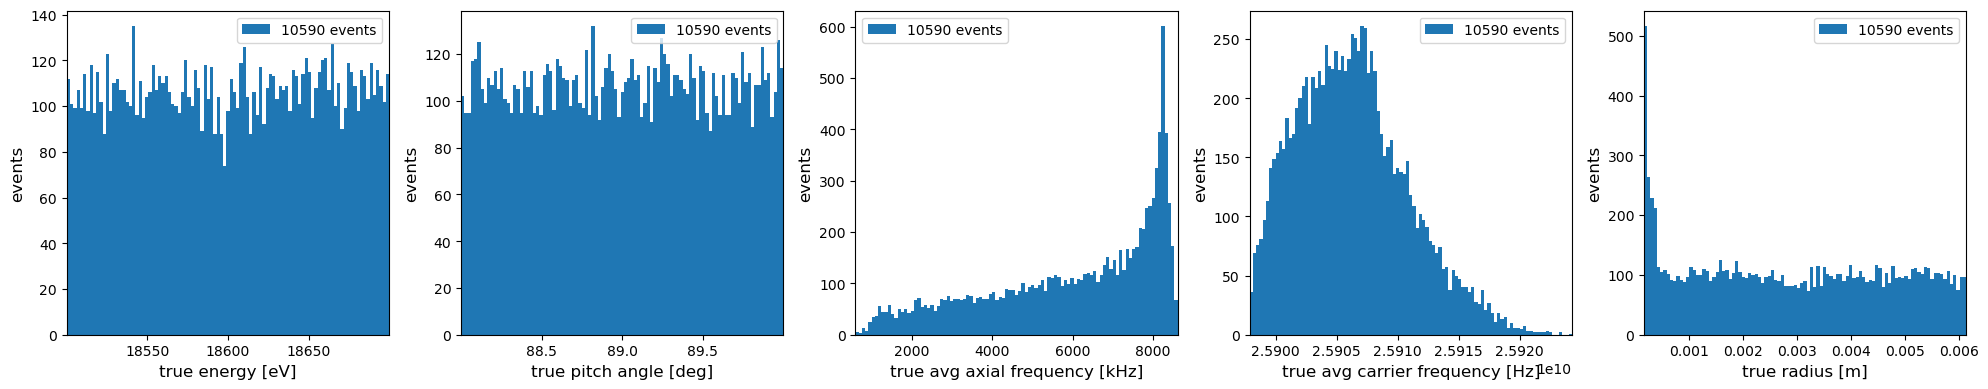

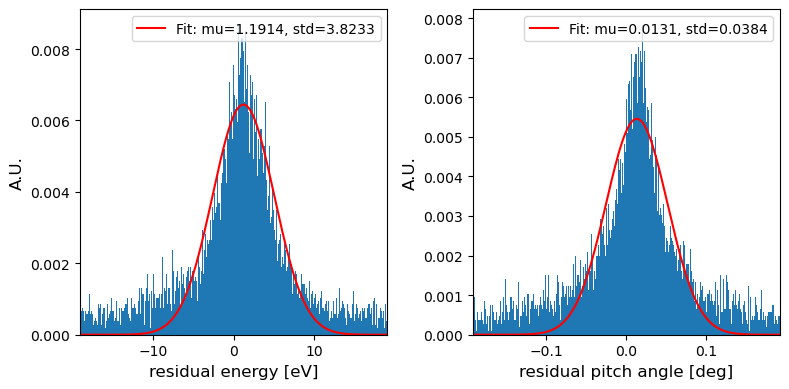

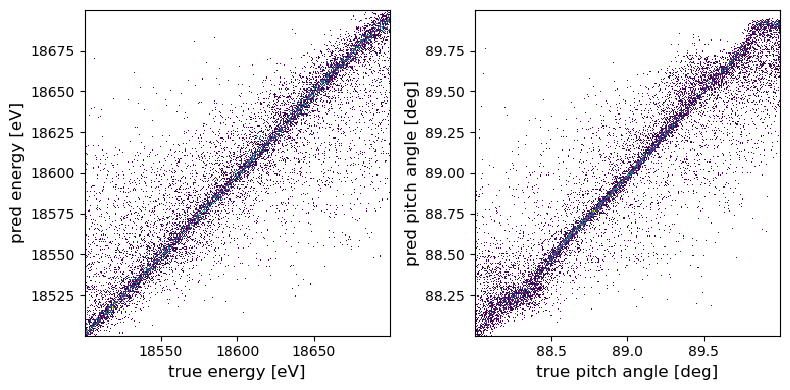

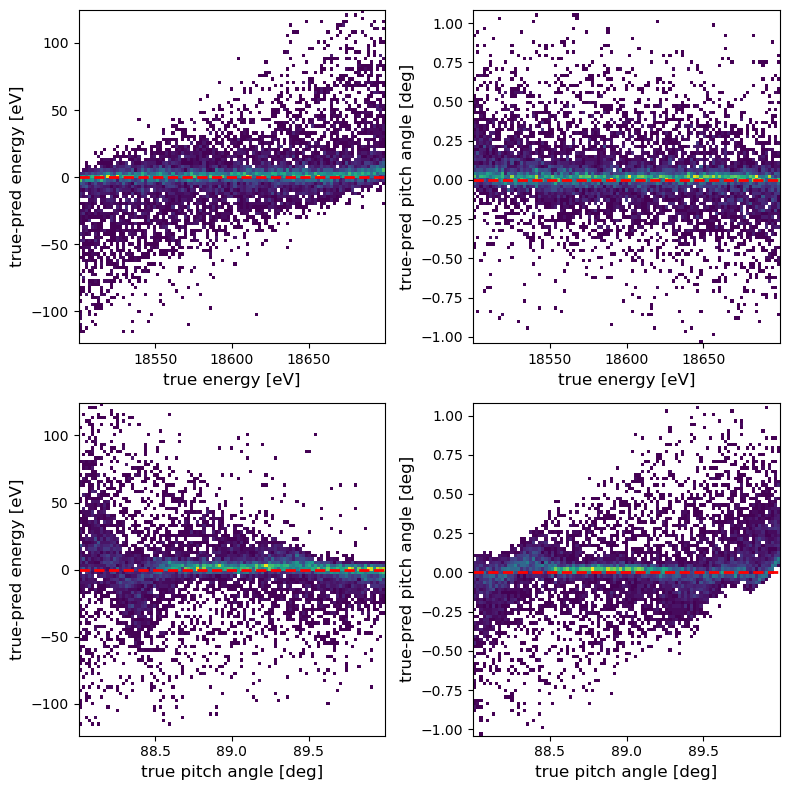

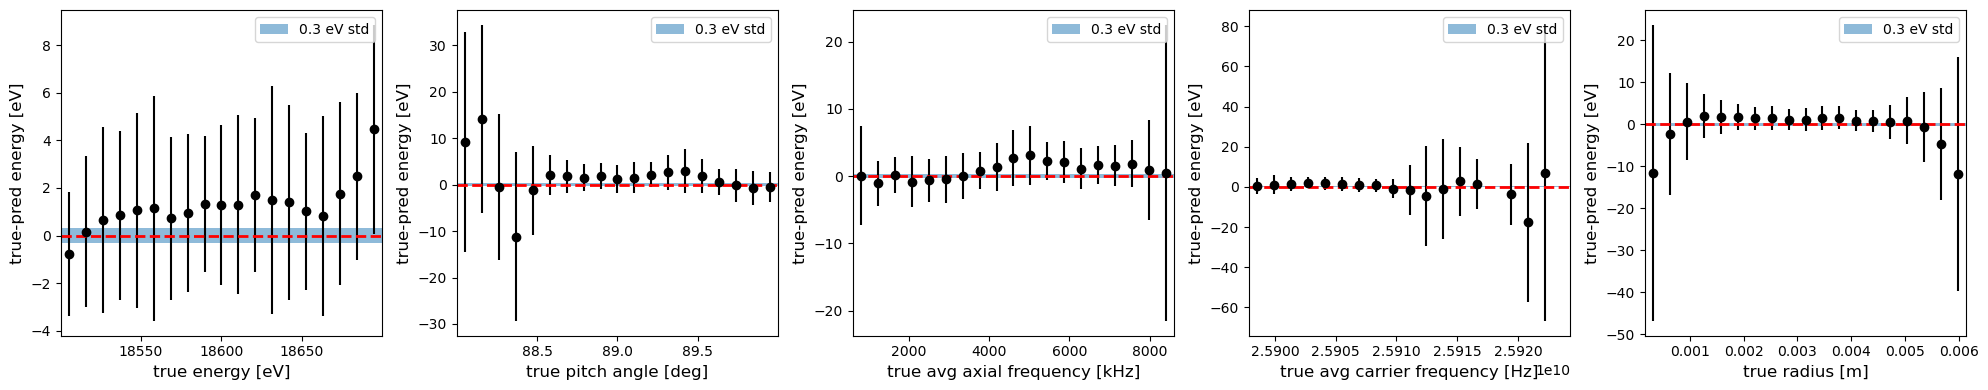

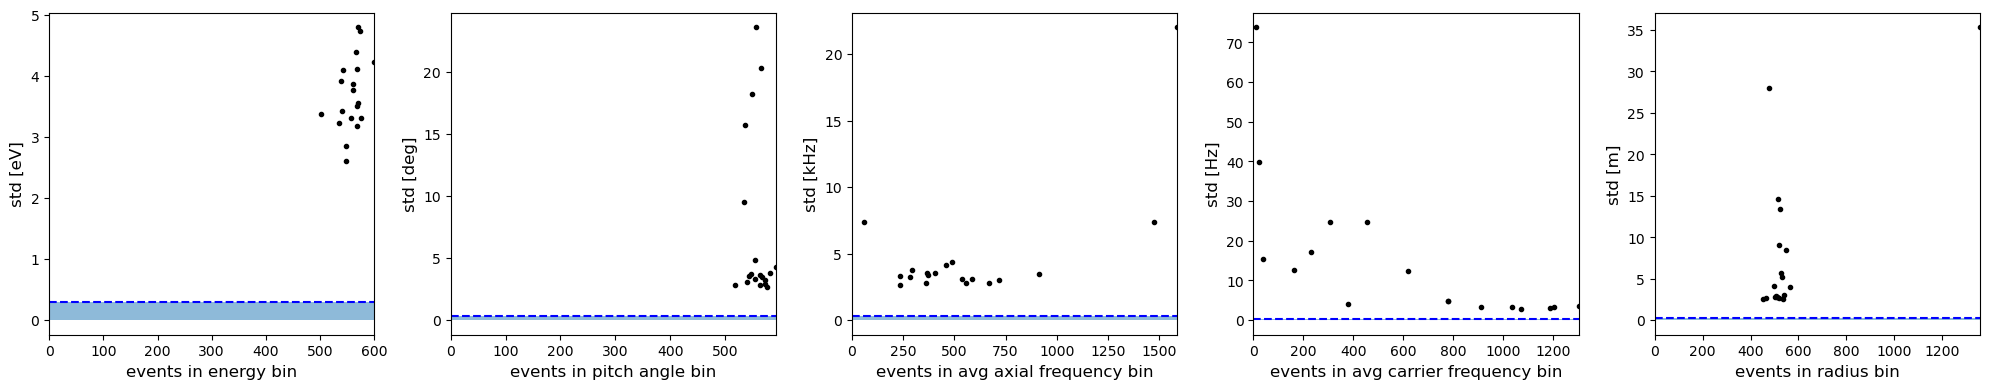

In [32]:
f = make_all_plots(dataset.variables, dataset.observables,true_post, pred_post, meta, folder=image_folder, savefigs=True)

In [37]:
import pickle

model = model.to(device)
model = model.eval()
#dataset = LitDataModule.load_from_checkpoint(CHECKPOINT)
inputs = ['output_ts_I', "output_ts_Q"]
variables = ['energy_eV', 'pitch_angle_deg']
observables = ['avg_axial_frequency_Hz', 'avg_carrier_frequency_Hz', 'radius_m']
shard_dir = '/home/lfd34/project/project8/ssm/neutrino_project/data_preprocessing/shards_20bins/'

total_num_bins = 15

true_list = []
pred_list = []
mean_arr = np.zeros(total_num_bins)
std_arr = np.zeros(total_num_bins)


base_dataset = Project8Sim(
    sorted(glob.glob(os.path.join(shard_dir, "*.hdf5"))),
    inputs,
    variables,
    observables,
    start=0,
    cutoff=8192,
    norm=True,
    noise_const=1,
    apply_filter=False,
    apply_fft=True
)

generator = torch.Generator().manual_seed(42)

train_len = int(0.8 * len(base_dataset))
val_len   = int(0.1 * len(base_dataset))
test_len  = len(base_dataset) - train_len - val_len

train_subset, val_subset, test_subset = random_split(
    base_dataset,
    [train_len, val_len, test_len],
    generator=generator
)

fixed_test_indices = test_subset.indices

for i in range(total_num_bins):

    print(f"Processing window {i+1}/{total_num_bins}")

    dataset = LitDataModule(
        shard_dir,
        inputs,
        variables,
        observables,
        start=8192*i,
        cutoff=8192*(i+1),
        norm=True,
        noise_const=1,
        apply_filter=False,
        apply_fft=True
    )

    dataset.test_dataset = Subset(dataset.dataset, fixed_test_indices)

    true = []
    pred = []

    for ts, var, obs in dataset.test_dataloader():
        with torch.no_grad():
            pred_batch = model(ts.to(device)).cpu().numpy()
            true_batch = var.numpy()

            pred.append(pred_batch)
            true.append(true_batch)

    true = np.concatenate(true, axis=0)
    pred = np.concatenate(pred, axis=0)

    pred_post = pred * dataset.stds + dataset.mu
    true_post = true * dataset.stds + dataset.mu

    true_list.append(true_post)
    pred_list.append(pred_post)

    mean_arr[i], std_arr[i] = get_res("energy_eV", true_post, pred_post)

data_dict = {
    "mean": mean_arr,
    "std": std_arr,
    "true": true_list,
    "pred": pred_list
}

with open("sliding_window.pkl", "wb") as file:
    pickle.dump(data_dict, file)

Processing window 1/15
Processing window 2/15
Processing window 3/15
Processing window 4/15
Processing window 5/15
Processing window 6/15
Processing window 7/15
Processing window 8/15
Processing window 9/15
Processing window 10/15
Processing window 11/15
Processing window 12/15
Processing window 13/15
Processing window 14/15
Processing window 15/15


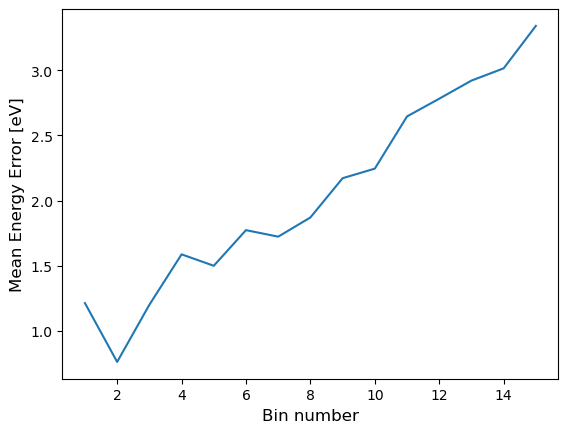

In [49]:
plt.xlabel("Bin number")
plt.ylabel("Mean Energy Error [eV]")
plt.plot(np.arange(1,total_num_bins + 1), mean_arr)

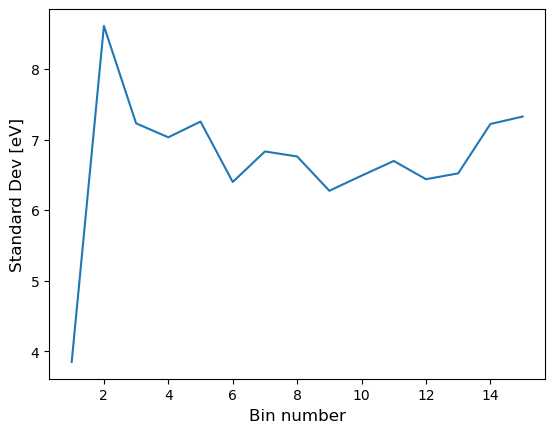

In [50]:
plt.xlabel("Bin number")
plt.ylabel("Standard Dev [eV]")

plt.plot(np.arange(1,total_num_bins + 1), std_arr)

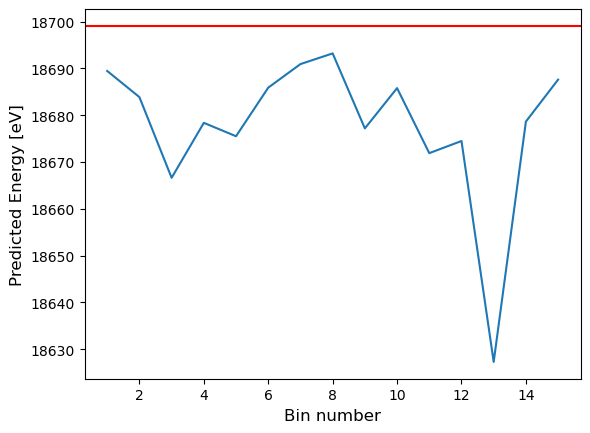

In [66]:
total_num_bins = 15
idx = 90
plt.xlabel("Bin number")
plt.ylabel("Predicted Energy [eV]")
pred_energy = [data_dict["pred"][i][idx,0] for i in range(len(data_dict["pred"]))]
plt.axhline(data_dict["true"][0][idx,0], color = "red")
plt.plot(np.arange(1,total_num_bins + 1), pred_energy)